# Introduction
In this lab, we will aim to determine the baseline of the fetal heart rate (FHR). The FHR is systematically recorded during every delivery as it reflects the oxygenation state of the fetus. Blood circulation, and thus oxygen flow, between the mother and fetus can be reduced or even stopped during contractions. Prolonged oxygen deficits lead to what is known as acidosis, which can cause irreversible neurological damage. It is therefore crucial to detect early warning signs to perform an emergency delivery (cesarean section or vacuum/forceps) in cases of risk.

When there is an oxygen deficit, the fetus's heart will initially show decelerations, which are visible in the FHR signal. However, analyzing the FHR can be quite challenging in some cases due to the issue of the baseline. In the example below, there are two very different ways to interpret this signal. Either the baseline is the blue line, corresponding to a normal baseline rate (at 130 bpm) with accelerations (which is healthy). Or the baseline is the red line, corresponding to tachycardia (at 170 bpm, which is pathological) accompanied by multiple decelerations (also pathological), making the FHR very concerning.

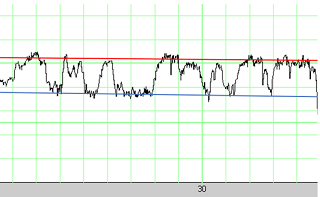

The correct answer here is the blue line (indicating a healthy rhythm), but this requires experience to identify, and many practitioners can make mistakes.

The first challenge for automatic FHR interpretation is determining this baseline. There is a kind of circular definition: the baseline is defined as the average FHR over 10 minutes, excluding decelerations and accelerations. Decelerations (or accelerations) are defined as periods lasting more than 15 seconds where the FHR deviates by more than 15 bpm from the baseline.

We will use a U-NET architecture to determine this baseline. Our initial approach will be to identify the curve closest to a reference baseline established by experts.

We have access to a public dataset of 67 annotated recordings published by the FMMS and GHICL teams, which we will segment into 34-minute recordings.

**Q1** How would you classify this type of problem? (classification/regression; supervised/unsupervised/reinforcement)?

**Answer:** Regression since we are predicting a quantitavie value the baseline. supervised since we have labels of what we want to predict

## Setup

**Q2** Import the libraries: numpy (np), tensorflow (tf), os, array, math, matplotlib.pyplot (plt), and add the shortcut `layers` from `tensorflow.keras`.

In [4]:
import numpy as np
import tensorflow as tf
import os
import array
import math
import matplotlib.pyplot as plt
from tensorflow.keras import layers

**Q3** The data file is available here: https://utsb-cloud.univ-catholille.fr/s/Kdw3MF6MXo7p5CL/download/pythonbaseline.zip. Download and unzip it in the current Colab folder.

In [5]:
!wget https://utsb-cloud.univ-catholille.fr/s/Kdw3MF6MXo7p5CL/download/pythonbaseline.zip
!unzip pythonbaseline.zip

--2026-02-09 12:48:32--  https://utsb-cloud.univ-catholille.fr/s/Kdw3MF6MXo7p5CL/download/pythonbaseline.zip
Resolving utsb-cloud.univ-catholille.fr (utsb-cloud.univ-catholille.fr)... 195.220.78.103
Connecting to utsb-cloud.univ-catholille.fr (utsb-cloud.univ-catholille.fr)|195.220.78.103|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://utsb-cloud.univ-catholille.fr/public.php/dav/files/Kdw3MF6MXo7p5CL/?accept=zip [following]
--2026-02-09 12:48:33--  https://utsb-cloud.univ-catholille.fr/public.php/dav/files/Kdw3MF6MXo7p5CL/?accept=zip
Reusing existing connection to utsb-cloud.univ-catholille.fr:443.
HTTP request sent, awaiting response... 200 OK
Length: 4822249 (4.6M) [application/zip]
Saving to: ‘pythonbaseline.zip.1’

pythonbaseline.zip. 100%[===================>]   4.60M   877KB/s    in 5.4s    

2026-02-09 12:48:38 (877 KB/s) - ‘pythonbaseline.zip.1’ saved [4822249/4822249]

Archive:  pythonbaseline.zip
replace pythonbaseline/f01.dat? [y]e

Below is the code to open each recording, subsample it at 0.5Hz, and segment it into 34-minute recordings (1024 temporal samples).

In [6]:
Lw = 32*64*4 # longuer d'une fenetre pour 4Hz
Lw8 = math.floor(Lw/8)#-1 # longueur d'une fenetre pour 0.5Hz
x = np.zeros([0,Lw8])
y = np.zeros([0,Lw8])
for i in range(1,67):
  Lfichier=os.path.getsize("pythonbaseline/f"+("%02d" % (i))+".dat")//8 # récupération de la longueur de chaque signal (en échantillon)
  floatmat=array.array("f")
  with open("pythonbaseline/f"+("%02d" % (i))+".dat", "rb") as binary_file:
      floatmat.fromfile(binary_file,Lfichier*2)
  data=np.asarray(floatmat.tolist()).reshape(-1,2)

  nbfenetre = math.floor(Lfichier/Lw) # calcul du nombre de fenetres (de 30mins) que contient chaque signal recupéré.
  for j in range(nbfenetre): # pour chaque fenetre,
    xWin = data[j*Lw:(j+1)*Lw,0] # extraire chaque 30 mins de cette fenetre
    yWin = data[j*Lw:(j+1)*Lw,1]

    xWinSub = np.zeros([1,Lw8])
    yWinSub = np.zeros([1,Lw8])
    for k in range(0,Lw8):
      x8 = xWin[k*8:(k+1)*8] #sous échantillonage à 8Hz
      y8 = yWin[k*8:(k+1)*8]
      #if((k+1)*8>=(yWin.shape[0])):
         #print(yWin.shape)
         #print((k+1)*8)
      yWinSub[0,k]  = np.mean(y8)
      xWinSub[0,k]= np.mean(x8[x8>0])
    x=np.concatenate((x,xWinSub),axis=0)
    y=np.concatenate((y,yWinSub),axis=0)


y = y[np.sum(np.isnan(x), axis=1) < 500, :]
x = x[np.sum(np.isnan(x), axis=1) < 500, :]






/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


**Q4** Display the size of `x`. What do the displayed values represent?

In [7]:
x.shape

(142, 1024)

**Answer:**

142 is the number of 34 minutes sections in the 66 files

1024 is the temporal samples

In [8]:
y.shape # same

(142, 1024)

**Q5** Normalize `x` and `y` by subtracting 120 and dividing by 60.

In [9]:
x=(x-120)/60
y=(y-120)/60

**Q6** Occasionally, the Doppler sensor recording the FHR loses the signal for brief periods. In these cases, `x` will contain `NaN` (Not a Number). These `NaN` values can cause numerical issues. A good way to handle them is to create a secondary variable, `xisnan = np.isnan(x)`.

Then replace all `NaN` values in the `x` array with zero. You can achieve this using boolean indexing with the `xisnan` array you just created (e.g., `x[xisnan] = 5` sets all `NaN` values in `x` to 5).

Create the variable `X` by concatenating `x` (with `NaN` values replaced) and the `xisnan` array along a new third axis. (Use the function `np.concatenate(...)` and ensure to add a third axis beforehand.)

*Warning: If an error occurs, `x` may be modified, so it is recommended to restart everything from question Q3.*

In [10]:
print(x.shape)
print(x[:,:,np.newaxis].shape)

(142, 1024)
(142, 1024, 1)


In [11]:
xisnan = np.isnan(x)
x[xisnan] = 0
X = np.concatenate((x[:,:,np.newaxis], xisnan[:,:,np.newaxis]), axis=2)

Verify that `X` has the size `(142, 1024, 2)`.

In [12]:
X.shape

(142, 1024, 2)

**Q7** Perform the train (60%), validation (20%), and test (20%) split, inspired by the code in Lab 3. First, calculate (in code) `n` as the total number of samples, and then calculate `n_train`, `n_val`, and `n_test` as the number of samples in each set. (You will need to use the `round` function for rounding.)

*Warning: Ensure that for any value of `n`, `n_train + n_val + n_test = n.` For example, if `n = 102`, then `n_train = 61`, `n_val = 20`, and `n_test = 21.`*

*Hint: What is `n_test` as a function of `n`, `n_train`, and `n_val`?*

In [13]:
n=X.shape[0]
n_train=round(n*0.6)
n_val=round(n*0.2)
n_test=n-n_train-n_val

#seed 42
np.random.seed(42)
indexes=np.arange(n) # 0,1,...,n-1
np.random.shuffle(indexes) # random order
X_train,Y_train= X[indexes[:n_train]],y[indexes[:n_train]]
X_val,Y_val= X[indexes[n_train:n_train+n_val]],y[indexes[n_train:n_train+n_val]]
X_test,Y_test= X[indexes[n_train+n_val:]],y[indexes[n_train+n_val:]]




Below is the code to display 2 or 3 signals at the correct scale. sig1, sig2, and sig3 are expected to be one-dimensional.

In [14]:
def plot_signals(sig1, sig2, sig3=None):
    time_scale = np.linspace(0, sig1.shape[0]/30, sig1.shape[0])
    fig, ax = plt.subplots(figsize=(12,6))

    ax.plot(time_scale,sig1*60+120 )
    ax.plot(time_scale,sig2*60+120 )
    if sig3 is not None:
      ax.plot(time_scale,sig3*60+120 )
    ax.set_xlim(0,35)
    ax.set_ylim(60, 220)
    plt.show()

**Q8** Using the previously defined function, display a signal (e.g., the 10th in the validation set) and its baseline.

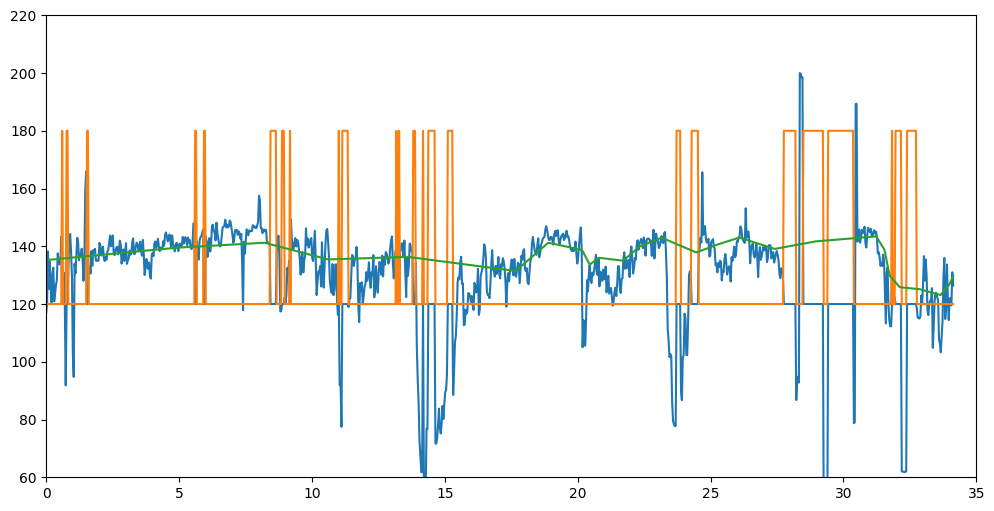

In [15]:
plot_signals(X_val[9,:,0],X_val[9,:,1],Y_val[9,:])

In [16]:
np.sum(xisnan)

np.int64(2376)

# Creating the First Model

We will adopt a U-NET architecture in which the resolution will be halved 6 times. Specifically, there will be 6 convolution blocks with max pooling, 2 central convolution blocks that do not change the resolution, and 6 deconvolution blocks.

**Q9** Why is the U-NET architecture suitable for our problem?

**Answer:** We want an output which have the same size of the input(except maybe the number of channels): for each time sample as input we have a time sample as output. We could call this "sync many to many". U-NET is a good architecture for that kind of topology.  

**Q10** Begin by defining the function:
```
def conv_block(inputs, filters, kernel_size=3, pool_size=2):
```
It will perform:
*   A 1D Convolution with `filters` filters, the specified `kernel_size`, and `padding='same'`
*   A BatchNormalization (syntax: `y = layers.BatchNormalization()(x)`)
*   A ReLU activation layer (syntax: `y = layers.Activation('relu')(x)`)
*   A MaxPooling1D (if `pool_size > 1`) with `padding='same'`

In [17]:
def conv_block(inputs, filters, kernel_size=3, pool_size=2):
  x = layers.Conv1D(filters, kernel_size, padding='same')(inputs)
  x = layers.BatchNormalization()(x)
  x = layers.Activation('relu')(x)
  if pool_size > 1:
    x = layers.MaxPooling1D(pool_size, padding='same')(x)
  return x



**Q11** Now create a deconvolution block with:
```
def deconv_block(inputs, skip_connection, filters, kernel_size=3):
```
It will perform:
*   `layers.UpSampling1D(size=2)` to double the sampling rate
*   Concatenate the upsampled tensor with the `skip_connection` tensor from the encoder at the same level (syntax: `y = layers.Concatenate(axis=1)([a, b])` concatenates `a` and `b` along axis 1 [(doc)](https://keras.io/api/layers/merging_layers/concatenate/))
*   A Conv1D with `filters` and `kernel_size`
*   A BatchNormalization
*   A ReLU activation

In [18]:
def deconv_block(inputs, skip_connection, filters, kernel_size=3):
    x=layers.UpSampling1D(size=2)(inputs)
    x = layers.Concatenate(axis=2)([x, skip_connection])
    x = layers.Conv1D(filters, kernel_size, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    return x

Now create the complete model using the two previously defined blocks.
There should be 7 descending stages using convolution blocks with a kernel size of 3, a max pool size of 2, and the number of filters set to 4, 4, 4, 8, 8, 12, 12, respectively.

Then, there are two central convolution blocks with a kernel size of 3, max pool size of 1 (i.e., no max pooling), and 12 filters each.

Following that, create 6 ascending stages using deconvolution blocks with a kernel size of 3, and the number of filters set to 12, 12, 8, 8, 4, 4, 4, respectively. Each of these blocks has two inputs, as a reminder.

Finally, add a last convolution layer for the output with a single filter. what should be the activation as this is a regression problem.

Display the summary of the created model.

*It is not required to use for loops to implement the 6 stages.*

In [19]:
inputs = layers.Input(shape=(1024, 2))

# 7 Descending stages
c1 = conv_block(inputs, 4, 3, 2)
c2 = conv_block(c1, 4, 3, 2)
c3 = conv_block(c2, 4, 3, 2)
c4 = conv_block(c3, 8, 3, 2)
c5 = conv_block(c4, 8, 3, 2)
c6 = conv_block(c5, 12, 3, 2)
c7 = conv_block(c6, 12, 3, 2)

# 2 Central blocks (no max pooling)
c_mid = conv_block(c7, 12, 3, 1)
c_mid = conv_block(c_mid, 12, 3, 1)

# 7 Ascending stages (using the 7 provided filter values)
u1 = deconv_block(c_mid, c6, 12, 3)
u2 = deconv_block(u1, c5, 12, 3)
u3 = deconv_block(u2, c4, 8, 3)
u4 = deconv_block(u3, c3, 8, 3)
u5 = deconv_block(u4, c2, 4, 3)
u6 = deconv_block(u5, c1, 4, 3)
u7 = deconv_block(u6, inputs, 4, 3)

# Final convolution layer
outputs = layers.Conv1D(1, 1, activation='linear')(u7)

model = tf.keras.Model(inputs=inputs, outputs=outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 1024, 2)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 1024, 4)   │         28 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 1024, 4)   │         16 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 1024, 4)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 512, 4)    │          0 │ activation[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 512, 4)    │         52 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512, 4)    │         16 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 512, 4)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 256, 4)    │          0 │ activation_1[0][… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 256, 4)    │         52 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 4)    │         16 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 256, 4)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_2     │ (None, 128, 4)    │          0 │ activation_2[0][… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 128, 8)    │        104 │ max_pooling1d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 8)    │         32 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 128, 8)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_3     │ (None, 64, 8)     │          0 │ activation_3[0][… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 64, 8)     │        200 │ max_pooling1d_3[… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 5,301 (20.71 KB)

 Trainable params: 5,045 (19.71 KB)

 Non-trainable params: 256 (1.00 KB)

**Q12** Define your usual callback, compile, and train. Use the Adam optimizer with a learning rate of 0.01, a batch size of 32, and 500 epochs. What should the loss function be?

In [20]:
callback = tf.keras.callbacks.ModelCheckpoint('best_model.keras', save_best_only=True, monitor='val_loss', mode='min',verbose=1)
# Regression problem so we use the mean squared error loss function
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss='mse')

history = model.fit(X_train, Y_train, batch_size=32, epochs=500, validation_data=(X_val, Y_val), callbacks=[callback])

Epoch 1/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - loss: 1.0909  
Epoch 1: val_loss improved from inf to 0.48570, saving model to best_model.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 33s 6s/step - loss: 1.0698 - val_loss: 0.4857
Epoch 2/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.4639
Epoch 2: val_loss improved from 0.48570 to 0.31766, saving model to best_model.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - loss: 0.4816 - val_loss: 0.3177
Epoch 3/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.1964
Epoch 3: val_loss improved from 0.31766 to 0.17376, saving model to best_model.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - loss: 0.2280 - val_loss: 0.1738
Epoch 4/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.3864
Epoch 4: val_loss improved from 0.17376 to 0.08028, saving model to best_model.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - loss: 0.2554 - val_loss: 0.0803
Epoch 5/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.3967
Epoch 5: val_loss improved from 0.08028 to 0.0595

**Q13** Load the best model and predict the baselines for the validation data. Calculate the root mean square error (RMSE) with `y_val`: `rmse = 60 * np.sqrt(np.mean((Y_val - Y_val_pred)**2))`. The multiplier of 60 is used to express the error in bpm. *Note: Both matrices must have the same number of dimensions before performing this operation.*

In [21]:
model=tf.keras.models.load_model('best_model.keras')
Y_val_pred=model.predict(X_val)
print(Y_val.shape)
print(Y_val_pred.shape)
rmse = 60 * np.sqrt(np.mean((Y_val[:,:,np.newaxis] - Y_val_pred)**2))
print(rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
(28, 1024)
(28, 1024, 1)
8.787376711665958


**Q14** Using the previously defined function, display for one recording the FHR signal, the theoretical baseline, and the predicted baseline. Test on several signals from the validation dataset.

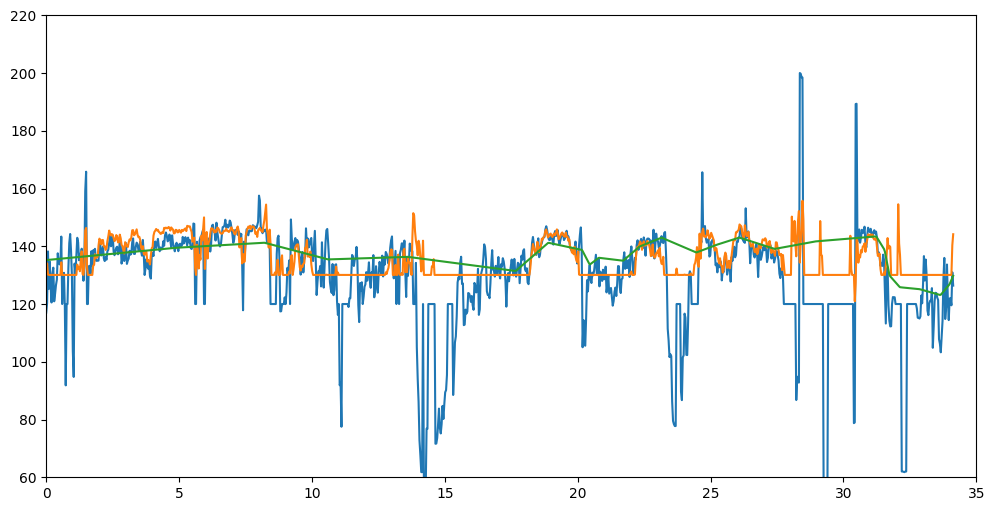

In [22]:
plot_signals(X_val[9,:,0],Y_val_pred[9,:,0],Y_val[9,:])

# Second Model
We have seen that there is a kind of circular definition for the baseline. In summary, the baseline is the average of the baseline periods, and the baseline periods are the times when the FHR does not deviate significantly from the baseline.

We will approach the problem differently by identifying baseline periods. This will no longer be a regression problem but a classification problem, as each FHR sample must be classified as a baseline point or not.

Two functions are provided to you:
* `LDB2state`: Converts baseline values into this classification for each temporal sample. *This function converts baseline values into baseline periods.*
* `state2LDB`: Converts the classification of samples back into baseline values.

In [23]:
def LDB2state(x,y):
    state = np.zeros((x.shape[0], x.shape[1]))

    # Appliquez les conditions pour définir 'state'
    state[x[:,:,1]==1] = -1
    state[(np.abs(x[:,:,0] - y) <= 8/60) & (x[:,:,1] == 0)] = 1
    state[(np.abs(x[:,:,0] - y) > 8/60) & (np.abs(x[:,:,0] - y) <= 15/60) & (x[:,:,1] == 0)] = 2
    state[(np.abs(x[:,:,0] - y) > 15/60) & (x[:,:,1] == 0)] = 0

    # Trouvez 'isbaseline'
    isbaseline = (state == 1)

    # Modifiez 'isbaseline' selon votre dernière condition
    for n in range(x.shape[0]):
        end_indices = np.where(np.diff(isbaseline[n,:]) == -1)[0]
        start_indices = np.where(np.diff(isbaseline[n,:]) == 1)[0]

        for e in end_indices:
            s = start_indices[start_indices > e]
            if s.size > 0:
                s = s[0]
                if (s - e <= 8) and np.all(state[n, s+1:e] != 2):
                    isbaseline[n, s:e] = 1

    isbaseline[x[:,:,1]==1] = 0

    return isbaseline
def LDB2state(x,y):
    state = np.zeros((x.shape[0], x.shape[1]))

    # Appliquez les conditions pour définir 'state'
    state[x[:,:,1]==1] = -1
    state[(np.abs(x[:,:,0] - y) <= 8/60) & (x[:,:,1] == 0)] = 1
    state[(np.abs(x[:,:,0] - y) > 8/60) & (np.abs(x[:,:,0] - y) <= 15/60) & (x[:,:,1] == 0)] = 2
    state[(np.abs(x[:,:,0] - y) > 15/60) & (x[:,:,1] == 0)] = 0

    # Trouvez 'isbaseline'
    isbaseline = (state == 1)

    # Modifiez 'isbaseline' selon votre dernière condition
    for n in range(x.shape[0]):
        end_indices = np.where(np.diff(isbaseline[n,:]) == -1)[0]
        start_indices = np.where(np.diff(isbaseline[n,:]) == 1)[0]

        for e in end_indices:
            s = start_indices[start_indices > e]
            if s.size > 0:
                s = s[0]
                if (s - e <= 8) and np.all(state[n, s+1:e] != 2):
                    isbaseline[n, s:e] = 1

    isbaseline[x[:,:,1]==1] = 0

    return isbaseline

def state2LDB(X, Y_pred):
    Y2tmp=(Y_pred>=0.5)  & (X[:,:,1:2] == 0)
    Yclass=Y2tmp[:,:,0]
    len_n, len_x = X.shape[0], X.shape[1]
    Y = np.zeros((len_n, len_x))

    for n in range(len_n):
        x = X[n, :, 0]
        yclass = Yclass[n, :]
        y = np.zeros(len_x)

        for k in range(len_x):
            values_to_consider = [x[k+i] for i in range(-15, 15) if 0 <= k+i < len_x and yclass[k+i]]
            if len(values_to_consider) > 10:
                y[k] = np.median(values_to_consider)
            else:
                y[k] = np.nan

        y[yclass==0] = np.nan

        nans = np.isnan(y)
        non_nans = ~nans
        indices = np.arange(len_x)

        y[nans] = np.interp(indices[nans], indices[non_nans], y[non_nans])
        Y[n, :] = y

    return Y


**Q15** Create `Y2_train`, `Y2_val`, and `Y2_test` using `LDB2state`.

In [24]:
Y2_train=1.*LDB2state(X_train,Y_train)
Y2_val=1.*LDB2state(X_val,Y_val)
Y2_test=1.*LDB2state(X_test,Y_test)

In [25]:
Y2_train.shape

(85, 1024)

**Q16** Copy your model but modify the last layer. What activation should be used? *Name this model `model2`.*

In [26]:
inputs = layers.Input(shape=(1024, 2))

# 7 Descending stages
c1 = conv_block(inputs, 4, 3, 2)
c2 = conv_block(c1, 4, 3, 2)
c3 = conv_block(c2, 4, 3, 2)
c4 = conv_block(c3, 8, 3, 2)
c5 = conv_block(c4, 8, 3, 2)
c6 = conv_block(c5, 12, 3, 2)
c7 = conv_block(c6, 12, 3, 2)

# 2 Central blocks (no max pooling)
c_mid = conv_block(c7, 12, 3, 1)
c_mid = conv_block(c_mid, 12, 3, 1)

# 7 Ascending stages (using the 7 provided filter values)
u1 = deconv_block(c_mid, c6, 12, 3)
u2 = deconv_block(u1, c5, 12, 3)
u3 = deconv_block(u2, c4, 8, 3)
u4 = deconv_block(u3, c3, 8, 3)
u5 = deconv_block(u4, c2, 4, 3)
u6 = deconv_block(u5, c1, 4, 3)
u7 = deconv_block(u6, inputs, 4, 3)

# Final convolution layer
outputs = layers.Conv1D(1, 1, activation='sigmoid')(u7)
model2 = tf.keras.Model(inputs=inputs, outputs=outputs)
model2.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 1024, 2)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_17 (Conv1D)  │ (None, 1024, 4)   │         28 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1024, 4)   │         16 │ conv1d_17[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_16       │ (None, 1024, 4)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_7     │ (None, 512, 4)    │          0 │ activation_16[0]… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_18 (Conv1D)  │ (None, 512, 4)    │         52 │ max_pooling1d_7[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512, 4)    │         16 │ conv1d_18[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_17       │ (None, 512, 4)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_8     │ (None, 256, 4)    │          0 │ activation_17[0]… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_19 (Conv1D)  │ (None, 256, 4)    │         52 │ max_pooling1d_8[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 4)    │         16 │ conv1d_19[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_18       │ (None, 256, 4)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_9     │ (None, 128, 4)    │          0 │ activation_18[0]… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_20 (Conv1D)  │ (None, 128, 8)    │        104 │ max_pooling1d_9[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 8)    │         32 │ conv1d_20[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_19       │ (None, 128, 8)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_10    │ (None, 64, 8)     │          0 │ activation_19[0]… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_21 (Conv1D)  │ (None, 64, 8)     │        200 │ max_pooling1d_10… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 5,301 (20.71 KB)

 Trainable params: 5,045 (19.71 KB)

 Non-trainable params: 256 (1.00 KB)

**Q17** Compile and train your model. What should the loss function and metric be? (Also remember to rename the model accordingly.)

In [27]:
callback = tf.keras.callbacks.ModelCheckpoint('best_model2.keras', save_best_only=True, monitor='val_loss', mode='min',verbose=1)

# Classification problem so we use binary_crossentropy
model2.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss='binary_crossentropy', metrics=['binary_accuracy'])

# Use Y2_train and Y2_val for classification targets
history = model2.fit(X_train, Y2_train, batch_size=32, epochs=500, validation_data=(X_val, Y2_val), callbacks=[callback])

Epoch 1/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - binary_accuracy: 0.5250 - loss: 0.7002  
Epoch 1: val_loss improved from inf to 0.73855, saving model to best_model2.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 27s 5s/step - binary_accuracy: 0.5333 - loss: 0.6958 - val_binary_accuracy: 0.3226 - val_loss: 0.7386
Epoch 2/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - binary_accuracy: 0.6629 - loss: 0.6335
Epoch 2: val_loss improved from 0.73855 to 0.71488, saving model to best_model2.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - binary_accuracy: 0.6764 - loss: 0.6255 - val_binary_accuracy: 0.3924 - val_loss: 0.7149
Epoch 3/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - binary_accuracy: 0.7191 - loss: 0.5916
Epoch 3: val_loss improved from 0.71488 to 0.68911, saving model to best_model2.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - binary_accuracy: 0.7198 - loss: 0.5928 - val_binary_accuracy: 0.5103 - val_loss: 0.6891
Epoch 4/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - binary_accuracy: 0.6962 - loss: 0.59

**Q18** Load the model at the best iteration, predict the classification of temporal samples on the validation data, convert this prediction into a baseline using `state2LDB`, and calculate the RMSE. Conclude in comparison to question 11.

In [28]:
model2 = tf.keras.models.load_model('best_model2.keras')
Y2_val_pred = model2.predict(X_val)

# Convert classification map to baseline values
Y_val_pred_m2 = state2LDB(X_val, Y2_val_pred)

# Calculate RMSE (ignoring NaNs that might result from state2LDB)
rmse_m2 = 60 * np.sqrt(np.nanmean((Y_val - Y_val_pred_m2)**2))
print(f"RMSE Model 2: {rmse_m2}")

# Compare with Model 1 (from previous output, e.g. ~8.3)
# print(f"Improvement: {rmse - rmse_m2}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
RMSE Model 2: 11.024621243102642


**Q19** In this lab, what could we have added to very likely improve the results of our models?

**Answer:** We should have done data augmentation : e.g. Time translation, Add a random small value to the FHR and to the baseline. We could also add simulated signal loss.

## Bidirectional RNN

Conitune the previous lab on determining the FHR baseline. One of the disadvantages of the previous method using CNN and U-NET is that it requires a fixed analysis time (set at 34 min). If we have longer signals, we could use sliding windows but it would create inconsistencies in the baseline between two windows. We'd also like to facilitate generalization: if we have a 3 min deceleration and a 5 min deceleration in the baseline train, we'd like a new 4 min deceleration to be easily interpreted as a deceleration, which is difficult with CNNs.

We're now going to create a model using GRU. Is it a one-to-many, many-to-one, sync many-to-many or async many-to-many model?

Create a model using two bidirectional GRU layers with 12 and 8 states respectively, you may need to use the return_sequences=true parameter depending on the previous question.
After each of these two layers, add Dropout at 0.1.

Add a dense output layer of 16 neurons (activation relu) with a dropout at 0.2, then the dense output layer (1 neuron without activation).

Why are there 24 channels at the output of the first bidirectional layer?

Train the model as last time and compare results



We have a sync many to many architecture: for every timestamp as input, we will have a corresponding timestamp as output.

In [29]:
inputs = layers.Input(shape=(1024, 2))

# First Bidirectional GRU layer
# return_sequences=True is needed because we want an output for every time step (sync many-to-many)
# Output dim = 12 * 2 = 24 because it concatenates forward and backward passes
x = layers.Bidirectional(layers.GRU(12, return_sequences=True))(inputs)
x = layers.Dropout(0.1)(x)

# Second Bidirectional GRU layer
x = layers.Bidirectional(layers.GRU(8, return_sequences=True))(x)
x = layers.Dropout(0.1)(x)

# Dense layers
x = layers.Dense(16, activation='relu')(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(1)(x)

model3 = tf.keras.Model(inputs=inputs, outputs=outputs)
model3.summary()

# Training
callback = tf.keras.callbacks.ModelCheckpoint('best_model3.keras', save_best_only=True, monitor='val_loss', mode='min', verbose=1)
model3.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss='mse')

history = model3.fit(X_train, Y_train, batch_size=32, epochs=500, validation_data=(X_val, Y_val), callbacks=[callback])

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 1024, 2)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 1024, 24)       │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024, 24)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 1024, 16)       │         1,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1024, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024, 16)       │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1024, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1024, 1)        │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,073 (12.00 KB)

 Trainable params: 3,073 (12.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - loss: 0.3788
Epoch 1: val_loss improved from inf to 0.05598, saving model to best_model3.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 604ms/step - loss: 0.3490 - val_loss: 0.0560
Epoch 2/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - loss: 0.1163
Epoch 2: val_loss did not improve from 0.05598
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 197ms/step - loss: 0.1335 - val_loss: 0.0733
Epoch 3/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - loss: 0.1691
Epoch 3: val_loss improved from 0.05598 to 0.04715, saving model to best_model3.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 233ms/step - loss: 0.1734 - val_loss: 0.0471
Epoch 4/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - loss: 0.1370
Epoch 4: val_loss improved from 0.04715 to 0.03542, saving model to best_model3.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 248ms/step - loss: 0.1439 - val_loss: 0.0354
Epoch 5/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - loss: 0.1390
Epoch 5: val_loss improved from 0.03542 to 0.03416, saving model to best_model

In [30]:
model=tf.keras.models.load_model('best_model3.keras')
Y_val_pred=model.predict(X_val)
print(Y_val.shape)
print(Y_val_pred.shape)
rmse = 60 * np.sqrt(np.mean((Y_val[:,:,np.newaxis] - Y_val_pred)**2))
print(rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step
(28, 1024)
(28, 1024, 1)
8.828033761397146


# Final Evaluation

We have completed all our tests and are satisfied with the results. It is now time for an unbiased evaluation.

**Q20** Load the best model between regression or classification based on your results and perform the RMSE evaluation on the test data.

In [31]:
model=tf.keras.models.load_model('best_model.keras')
Y_test_pred=model.predict(X_test)

rmse = 60 * np.sqrt(np.mean((Y_test[:,:,np.newaxis] - Y_test_pred)**2))
print(rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
9.72575954842826


**Q21** Display on the same plot from the test dataset the theoretical baseline, the baseline from the first model, and the baseline from the second model.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step


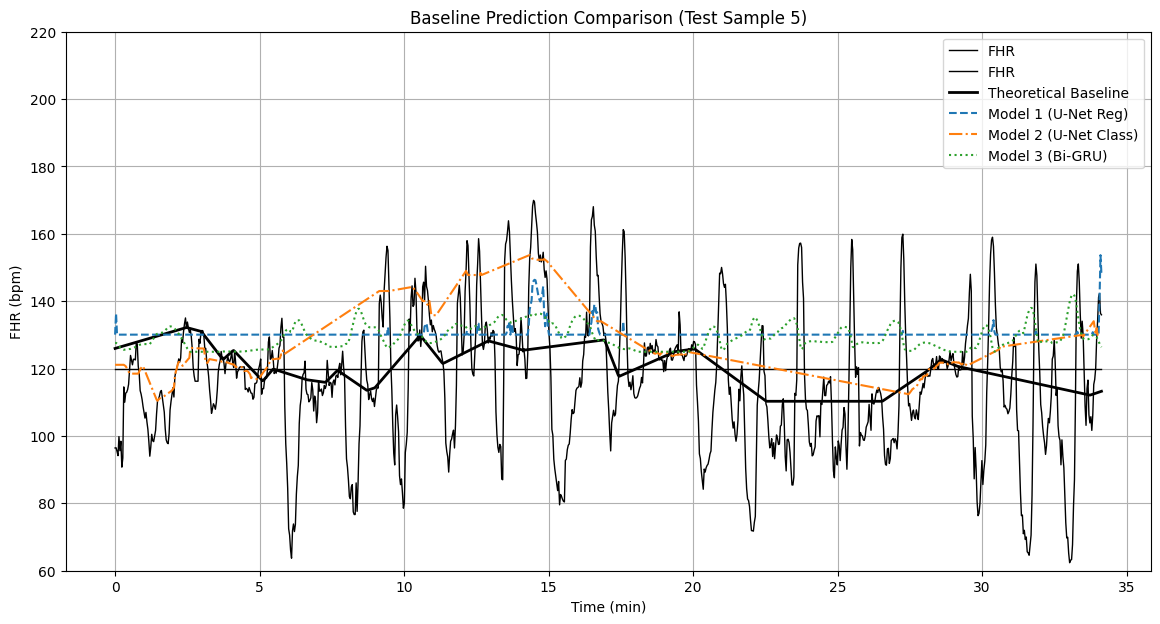

In [33]:
# Load Model 2 and predict
model2 = tf.keras.models.load_model('best_model2.keras')
Y2_test_pred_raw = model2.predict(X_test)
Y_test_pred_m2 = state2LDB(X_test, Y2_test_pred_raw)

# Load Model 3 and predict
model3 = tf.keras.models.load_model('best_model3.keras')
Y_test_pred_m3 = model3.predict(X_test)

# Plotting
idx = 5  # Select an arbitrary index from the test set
time_scale = np.linspace(0, 1024/30, 1024)

plt.figure(figsize=(14, 7))
plt.plot(time_scale, X_test[idx] * 60 + 120, label='FHR', color='black', linewidth=1)
plt.plot(time_scale, Y_test[idx] * 60 + 120, label='Theoretical Baseline', color='black', linewidth=2)
plt.plot(time_scale, Y_test_pred[idx].flatten() * 60 + 120, label='Model 1 (U-Net Reg)', linestyle='--')
plt.plot(time_scale, Y_test_pred_m2[idx] * 60 + 120, label='Model 2 (U-Net Class)', linestyle='-.')
plt.plot(time_scale, Y_test_pred_m3[idx].flatten() * 60 + 120, label='Model 3 (Bi-GRU)', linestyle=':')

plt.title(f'Baseline Prediction Comparison (Test Sample {idx})')
plt.xlabel('Time (min)')
plt.ylabel('FHR (bpm)')
plt.ylim(60, 220)
plt.legend()
plt.grid(True)
plt.show()